In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
# from selenium.webdriver.support.expected_conditions import none_of

plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline
from sklearn.preprocessing import StandardScaler
plt.rc("font", weight="bold")  # 全局字体设定
plt.rc("axes", labelweight="bold", titleweight="bold")  # 坐标轴标签 & 标题加粗
plt.rc("legend",  frameon=False)  # 图例字体大小 & 取消边框

In [2]:
dfmusic = pd.read_pickle("music_var_chordkey.pkl")
dfbasic = pd.read_pickle("soundfeature_other.pkl")

In [3]:
# 去除重复列
dfbasic = dfbasic.loc[:, ~dfbasic.columns.duplicated()]
dfmusic =dfmusic.loc[:, ~dfmusic.columns.duplicated()]

In [4]:
df = pd.merge(dfmusic,dfbasic ,on=['file'], how='left', suffixes=('', '_drop'))
df = df[[col for col in df.columns if not col.endswith('_drop')]]

In [5]:
# 精简版类别
SIMPLE_CATEGORIES = [
    "Song",
    "Alarm Call",
    "Flight Call",
    "Nocturnal Flight Call",
    "Begging Call",
    "Courtship Call",
    "Social Call",
    "Display Sound",
    "Wing Sounds",
    "Call" 
]

# 复杂版类别
DETAILED_CATEGORIES = [
    "Song",
    "Alarm Call",
    "Nocturnal Flight Call",
    "Flight Call",
    "Begging Call",
    "Courtship Call",
    "Social Call",
    "Display Sound",
    "Wing Sounds",
    "Imitation",
    "Chatter",
    "Duet",
    "Whisper Song",
    "Territorial Call",
    "Distress Call",
    "Interaction Call",
    "Mating Call",
    "General Call"  
]

# 关键词匹配表（扩展 Call 分类）
CATEGORY_KEYWORDS = {
    "Song": ["song", "subsong", "full song", "plastic song", "whisper song"],
    "Alarm Call": ["alarm call", "distress call", "mobbing call", "outburst"],
    "Nocturnal Flight Call": ["nocturnal flight call", "nfc", "night", "nocturnal"],
    "Flight Call": ["flight call", "migration call"],
    "Begging Call": ["begging call", "chicks calling", "hatchling", "nestling"],
    "Courtship Call": ["courtship call", "male courtship", "female quacking", "mating"],
    "Social Call": ["social call", "contact call", "flock", "parades", "greeting"],
    "Display Sound": ["display", "advertisement call", "whistle", "bubbling"],
    "Wing Sounds": ["wing", "wingbeat", "wing noise", "wing flutter", "wings", "wing whistle"],
    "Imitation": ["imitation", "mimicry", "mimicry/imitation"],
    "Chatter": ["chatter", "husky chatter"],
    "Duet": ["duet", "pair flushed"],
    "Whisper Song": ["whisper song"],
    "Territorial Call": ["territorial call"],
    "Distress Call": ["distress call"],
    "Interaction Call": ["interaction calls", "conflict call"],
    "Mating Call": ["mating season", "copulation", "agitation call"],
    "General Call": ["call"]  
}

# 分类函数
def classify_sound_type(type_str, mode="detailed"):
    """ 根据 mode ('simple' or 'detailed') 进行分类 """
    if pd.isna(type_str) or type_str.strip() == "":
        return "Unclassified" if mode == "simple" else ["Unclassified"]

    type_str = type_str.lower()  # 统一转换为小写
    matched_categories = [category for category, keywords in CATEGORY_KEYWORDS.items() if any(keyword in type_str for keyword in keywords)]

    if mode == "simple":
        # 选择 **匹配度最高的类别**
        for category in SIMPLE_CATEGORIES:
            if category in matched_categories:
                return category
        return "Call"  # 如果是未分类的 Call，则归入 "Call"
    
    return matched_categories if matched_categories else ["Unclassified"]  # 确保不会出现 "Other"

# 应用分类（精简版 & 复杂版）
df["sound_category_simple"] = df["type"].apply(lambda x: classify_sound_type(x, mode="simple"))
df["sound_category_detailed"] = df["type"].apply(lambda x: classify_sound_type(x, mode="detailed"))

In [6]:
# 栖息地分类映射
habitat_mapping = {
    'Aquatic and Wetland Surface Birds': ['Eurasian Wigeon', 'Tundra Swan', 'Mallard', 
                                          'Greater White-fronted Goose', 'Common Goldeneye', 
                                          'Green-winged Teal', 'Eurasian Coot', 'Eurasian Moorhen','Common Moorhen','Eurasian Teal'],

    'Shoreline and Marsh Birds': ['Eurasian Curlew', 'Whimbrel','Eurasian Whimbrel'],

    'Grassland Ground Birds': ['Olive-backed Pipit', 'Yellow-browed Bunting', 'Yellow-billed Grosbeak'],

    'Shrub Layer Birds': ['Light-vented Bulbul', 'Chinese Hwamei', 'Japanese Tit', 
                          'Silver-throated Tit', 'Chinese Blackbird', 'Pale-legged Leaf Warbler','Silver-throated Bushtit'],

    'Lower Canopy Birds': ['Pale Thrush', 'Oriental Magpie'],

    'Upper Canopy and Aerial Birds': ["Swinhoe's White-eye"]
}

# 将所有物种映射到栖息地类别
species_to_habitat = {}
for habitat, species_list in habitat_mapping.items():
    for species in species_list:
        species_to_habitat[species] = habitat

# 分类函数
def classify_bird_habitat(species):
    return species_to_habitat.get(species, 'Other')  # 若未匹配到则归类为 'Other'

bird_name_mapping = {
    'Eurasian Teal': 'Eurasian Moorhen',
    'Silver-throated Bushtit': 'Silver-throated Tit',
    'Common Moorhen': 'Eurasian Moorhen', 
    'Eurasian Whimbrel': 'Whimbrel'  
}

# 先转换 `birdenname`
df['bird'] = df['birdenname'].replace(bird_name_mapping)

# 应用分类函数
df['habitat'] = df['bird'].copy().apply(classify_bird_habitat)

# 应用分类函数
df['habitat'] = df['birdenname'].copy().apply(classify_bird_habitat)

# 根据分类映射顺序创建分类类型
habitat_order = list(habitat_mapping.keys())
df['habitat'] = pd.Categorical(df['habitat'], categories=habitat_order, ordered=True)

In [7]:
# df = df[df["type"].str.contains("song", case=False, na=False)] 

In [8]:
# 解析 chord 变量为列表
df['chord'] = df['chord'].str.strip('{}').str.split(',')

In [9]:
df = df.explode('chord').rename(columns={'chord': 'event'})

In [10]:
# 计算 event 的出现次数
event_counts = df['event'].value_counts()
# 计算 event 占比
event_ratio = event_counts / len(df)
# 选择占比 >= 5% 的 event
valid_events = event_ratio[event_ratio >= 0.01].index
# 过滤 DataFrame
df = df[df['event'].isin(valid_events)]

In [11]:
# chroma_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
# minor_chords = [s + 'm' for s in chroma_labels]  # 小三和弦
# major_chords = chroma_labels  # 大三和弦
# chord_labels = major_chords + minor_chords  # 共24个和弦
# # 创建一个和弦标签的字典，用于快速查找和弦的索引
# chord_index = {chord: idx for idx, chord in enumerate(chord_labels)}
# 
# # 创建一个numpy零矩阵，用于存储哑变量
# dummy_matrix_np = np.zeros((df.shape[0], len(chord_labels)), dtype=int)
# 
# # 遍历df_selected的每一行，构建哑变量矩阵
# for idx, chords in enumerate(df['chord']):
#     # 获取和弦列表对应的索引位置
#     chord_indices = [chord_index[chord] for chord in chords]
#     # 设置对应的位置为1
#     dummy_matrix_np[idx, chord_indices] = 1
# 
# # 将numpy矩阵转换为pandas DataFrame
# dummy_matrix = pd.DataFrame(dummy_matrix_np, columns=chord_labels)

In [12]:
df=df.reset_index(drop='True')

In [13]:
df = df.sample(frac=1, random_state=42)

# 如果你想重置索引，可以使用：
df = df.reset_index(drop=True)

In [14]:
chord_df = pd.get_dummies(df['event'], prefix='', prefix_sep='')
# chord_df=dummy_matrix
chord_df = chord_df.astype(int)
soundscape_columns = ['ZCR',
       'MEANt', 'VARt', 'SKEWt', 'KURTt', 'LEQt', 'BGNt', 'SNRt', 'MED', 'Ht',
       'ACTtFraction', 'ACTtCount', 'ACTtMean', 'EVNtFraction', 'EVNtMean',
       'EVNtCount', 'MEANf', 'VARf', 'SKEWf', 'KURTf', 'NBPEAKS', 'LEQf',
       'ENRf', 'BGNf', 'SNRf', 'Hf', 'EAS', 'ECU', 'ECV', 'EPS', 'EPS_KURT',
       'EPS_SKEW', 'ACI', 'NDSI', 'rBA', 'AnthroEnergy', 'BioEnergy', 'BI',
       'ROU', 'ADI', 'AEI', 'LFC', 'MFC', 'HFC', 'ACTspFract', 'ACTspCount',
       'ACTspMean', 'EVNspFract', 'EVNspMean', 'EVNspCount', 'TFSD',
       'H_Havrda', 'H_Renyi', 'H_pairedShannon', 'H_gamma', 'H_GiniSimpson',
       'RAOQ', 'AGI', 'ROItotal', 'ROIcover']
# soundscape_columns =['MEANf', 'VARf', 'NBPEAKS', 'LEQf', 'ACI', 'NDSI', 'BI', 'H_pairedShannon']

soundscape=df[soundscape_columns].copy()
scaler = StandardScaler()
soundscape_scaled = scaler.fit_transform(soundscape)
soundscape_scaled = pd.DataFrame(soundscape_scaled, columns=soundscape.columns)



combined_df = pd.concat([soundscape_scaled, chord_df], axis=1)
# combined_df = chord_df
classdf=df['birdenname'].copy()
habitatdf=df['habitat'].copy()
type=df['sound_category_simple'].copy()

In [15]:
X = combined_df
X = X.fillna(X.mean())
# y = pd.get_dummies(habitatdf)
y1=pd.get_dummies(classdf)
X2=pd.get_dummies(type)
X3=pd.get_dummies(df['cnt'].copy())
X=pd.concat([X, X2,X3], axis=1)
y2 = pd.get_dummies(habitatdf)
y=pd.concat([y1, y2], axis=1)
y=y2.astype(int)


In [16]:
# # from sklearn.preprocessing import LabelEncoder
# # # 复制数据
# # classdf_encoded = classdf.copy()
# # le = LabelEncoder()
# # classdf_encoded = le.fit_transform(classdf)  
# 
# X = combined_df
# X = X.fillna(X.mean())
# # y = pd.get_dummies(habitatdf)
# y1=pd.DataFrame(classdf_encoded,columns=['bird'])
# # y1=pd.get_dummies(classdf)
# X=pd.concat([X,y1], axis=1)
# y2 = pd.get_dummies(habitatdf)
# y=pd.concat([y1, y2], axis=1)
# y=y2.astype(int)

In [17]:
# X.to_csv('X.csv')
# y.to_csv('y.csv')

In [18]:
from sklearn.cross_decomposition import PLSCanonical
cca = PLSCanonical(n_components=2,max_iter=1000)
cca_results, _ = cca.fit_transform(X, y)

In [19]:

#  将 CCA 结果转换为 DataFrame
df_cca = pd.DataFrame(cca_results, columns=['CCA1', 'CCA2'])
# 计算旋转矩阵
theta = np.radians(-45)  # 旋转 185 度
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                            [np.sin(theta), np.cos(theta)]])

# 旋转数据
df_cca[['CCA1', 'CCA2']] = np.dot(df_cca[['CCA1', 'CCA2']], rotation_matrix)

df_cca['bird'] = classdf
df_cca['habitat'] = habitatdf
scalercca = StandardScaler()
df_cca[['CCA1', 'CCA2']] = scalercca.fit_transform(df_cca[['CCA1', 'CCA2']])

In [20]:
habitat_order = list(habitat_mapping.keys())
# habitat_order = df_cca['habitat'].unique()
df_cca['habitat'] = pd.Categorical(df_cca['habitat'], categories=habitat_order, ordered=True)

In [21]:
from scipy.stats import zscore
df_cca[['CCA1_z', 'CCA2_z']] = df_cca[['CCA1', 'CCA2']].apply(zscore)
df_cca = df_cca[(df_cca['CCA1_z'].abs() <= 3) & (df_cca['CCA2_z'].abs() <= 3)]
df_cca = df_cca.drop(columns=['CCA1_z', 'CCA2_z'])


habitat_factors = {habitat: 2 for i, habitat in enumerate(df_cca['habitat'].unique())}
df_cca['distance'] = np.sqrt(df_cca['CCA1']**2 + df_cca['CCA2']**2)
df_cca['CCA1_unit'] = df_cca['CCA1'] / df_cca['distance']
df_cca['CCA2_unit'] = df_cca['CCA2'] / df_cca['distance']
df_cca['scale_factor'] = df_cca['habitat'].astype(str).map(habitat_factors)
df_cca['CCA1'] = df_cca['CCA1_unit'] * df_cca['distance'] * df_cca['scale_factor']
df_cca['CCA2'] = df_cca['CCA2_unit'] * df_cca['distance'] * df_cca['scale_factor']


from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-3, 3))  # 归一化到 [-1, 1]
df_cca[['CCA1', 'CCA2']] = scaler.fit_transform(df_cca[['CCA1', 'CCA2']])

In [22]:
#计算和弦的中心点向量
vectors = cca.x_weights_  # CCA对和弦的向量表示
vectors = pd.DataFrame(vectors, columns=['CCA1', 'CCA2'])
vectors[['CCA1', 'CCA2']] = np.dot(vectors[['CCA1', 'CCA2']], rotation_matrix)
vectors = scalercca.transform(vectors)
# 创建一个列表来存储所有和弦的名称和长度
all_chords = []
chord_lengths = []  # 用于存储所有和弦的长度

# 计算每个和弦的长度
for i, event in enumerate(combined_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(vectors[i, 0]**2 + vectors[i, 1]**2)
    
    # 将和弦名称和对应长度添加到列表
    all_chords.append(event)
    chord_lengths.append(vector_length)

# 将和弦名称和长度转换为数据框
df_lengths = pd.DataFrame({
    'Chord': all_chords,
    'Length': chord_lengths
})

mean_length = df_lengths['Length'].mean()
std_length = df_lengths['Length'].std()
sem_length = df_lengths['Length'].sem()
#对和弦长度进行标准归一化 (Z-score 标准化)
scaler = StandardScaler()
df_lengths['Standardized_Length'] = scaler.fit_transform(df_lengths[['Length']])

In [23]:
vectors = pd.DataFrame(vectors, columns=['CCA1', 'CCA2'],index=X.columns)

In [24]:
mean_length

np.float64(0.035858660150647044)

In [25]:
mean_length

np.float64(0.035858660150647044)

In [26]:
from palettable.tableau import Tableau_10
from adjustText import adjust_text
import matplotlib.patheffects as path_effects
from palettable.tableau import Tableau_20

C:\Users\aa271\AppData\Local\Temp\ipykernel_9864\348442825.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bird_mean = df_cca.groupby("habitat")[['CCA1', 'CCA2']].mean()
C:\Users\aa271\AppData\Local\Temp\ipykernel_9864\348442825.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bird_std = df_cca.groupby("habitat")[['CCA1', 'CCA2']].std()
C:\Users\aa271\AppData\Local\Temp\ipykernel_9864\348442825.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

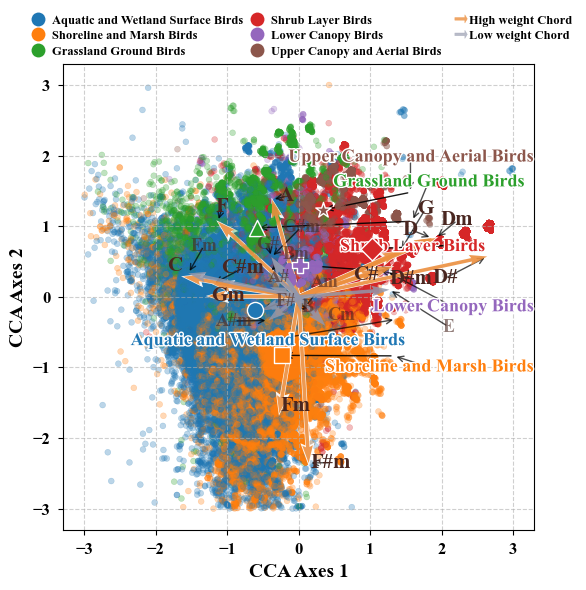

In [27]:

cmap=Tableau_10.mpl_colors[0:6] 

# 绘制 CCA 散点图，并标注鸟类的中心点
fig, ax = plt.subplots(figsize=(6, 6))
habitat_colors = dict(zip(habitat_order, cmap))  # 确保顺序一致


df_cca['habitat_str'] = df_cca['habitat'].astype(str)
bird_mean = df_cca.groupby("habitat")[['CCA1', 'CCA2']].mean()
bird_std = df_cca.groupby("habitat")[['CCA1', 'CCA2']].std()
df_cca['CCA1_std'] = df_cca['habitat_str'].map(bird_std['CCA1'])
df_cca['CCA2_std'] = df_cca['habitat_str'].map(bird_std['CCA2'])
df_cca['CCA1_mean'] = df_cca['habitat_str'].map(bird_mean['CCA1'])
df_cca['CCA2_mean'] = df_cca['habitat_str'].map(bird_mean['CCA2'])


# 计算标准化的欧几里得距离
df_cca['std_distance'] = np.sqrt(
    ((df_cca['CCA1'] - df_cca['CCA1_mean']) / df_cca['CCA1_std']) ** 2 +
    ((df_cca['CCA2'] - df_cca['CCA2_mean']) / df_cca['CCA2_std']) ** 2
)

# 设定 sigma 半径（可调整）
sigma_radius = 2
df_cca['in_sigma'] = df_cca['std_distance'] <= sigma_radius
df_cca['zorder'] = df_cca['in_sigma'].astype(int)
df_cca = df_cca.sort_values(by="zorder", ascending=True)

# 设定第二个 sigma 半径
sigma_radius2 = 0.5

# 0.5 σ 内优先级（上层到下层）
priority_order = [
    'Lower Canopy Birds', 
    'Upper Canopy and Aerial Birds', 
    'Grassland Ground Birds', 
    'Shoreline and Marsh Birds', 
    'Shrub Layer Birds', 
    'Aquatic and Wetland Surface Birds'
]

# 计算在 `sigma_radius2` 以内的点
df_cca['in_sigma2'] = df_cca['std_distance'] <= sigma_radius2

# 按照 `priority_order` 赋予 `zorder`
priority_dict = {habitat: len(priority_order) - i for i, habitat in enumerate(priority_order)}
df_cca['priority_zorder'] = df_cca['habitat_str'].map(priority_dict)

# `sigma_radius2` 内的点优先级最高
df_cca.loc[df_cca['in_sigma2'], 'zorder'] = df_cca['priority_zorder']

# 确保 `zorder` 递增排列
df_cca = df_cca.sort_values(by="zorder", ascending=True)


for z in sorted(df_cca['zorder'].unique()):
    subset = df_cca[df_cca['zorder'] == z]
    sns.scatterplot(
        x='CCA1', y='CCA2', hue='habitat', data=subset,
palette=cmap, s=18, alpha=0.3, edgecolor=None, ax=ax,  zorder=z
    )


# # 先绘制外点
# sns.scatterplot(
#     x='CCA1', y='CCA2', hue='habitat', data=df_cca[df_cca['zorder'] == 0],
#     palette=cmap, s=18, alpha=0.3, edgecolor=None, ax=ax, zorder=0
# )
# 
# # 再绘制内点，确保它们不被覆盖
# sns.scatterplot(
#     x='CCA1', y='CCA2', hue='habitat', data=df_cca[df_cca['zorder'] == 1],
#     palette=cmap, s=18, alpha=0.3, edgecolor=None, ax=ax, zorder=1
# )


# # # 使用 seaborn 绘制散点图，并设置透明度、调色板、点大小等参数
# scatter = sns.scatterplot(
#     x='CCA1', y='CCA2', hue='habitat', data=df_cca, 
#     palette=cmap, s=18, alpha=0.3, edgecolor=None,ax=ax
# )
# 


# 计算鸟类的中心点
bird_centroids = df_cca.groupby("habitat")[['CCA1', 'CCA2']].mean()
# Step 5: 标注鸟类的中心点
markers = ['o', 's', '^', 'D', 'P', '*', 'X', 'v']  # 可以选择不同的形状
marker_map = dict(zip(habitat_order, markers[:len(habitat_order)]))  # 给每个 habitat 分配一个形状
texts = []
for i, bird in enumerate(bird_centroids.index):
    habitat = df_cca.loc[df_cca['habitat'] == bird, 'habitat'].values[0]  # 找到该鸟类对应的 habitat
    color = habitat_colors[habitat]  # 获取对应 habitat 的颜色
    
    # # 添加文本并设置描边效果
    text = ax.text(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1], bird,
                   fontsize=13, weight='bold', color=color, zorder=10,
                   path_effects=[path_effects.Stroke(linewidth=2, foreground='white'),
                                 path_effects.Normal()])  # 白色描边
    
    marker = marker_map[habitat]  # 根据 habitat 获取对应的形状
    # Step 2.1: 绘制点，点的大小为 100，形状根据 habitat 分配
    ax.scatter(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1], 
               s=135, color=color, marker=marker, edgecolor='white', zorder=20, linewidth=1)
    
    texts.append(text)
    
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='->,head_width=0.2,head_length=0.4',
        color='black',
        lw=1,
        alpha=0.9
    ),
    force_points=0.5,  # 力度调节，避免重叠
    expand_points=(1, 1),  # 让文本与点之间有额外的空间
    ax=ax, zorder=6  # 使用 ax 对象进行调整
)

# 计算和弦的中心点向量
chord_vectors = cca.x_weights_[:chord_df.shape[1], :]  # CCA对和弦的向量表示
chord_vectors = pd.DataFrame(chord_vectors, columns=['CCA1', 'CCA2'])
chord_vectors[['CCA1', 'CCA2']] = np.dot(chord_vectors[['CCA1', 'CCA2']], rotation_matrix)
chord_vectors = scalercca.transform(chord_vectors)
# 创建一个列表来存储未被过滤掉的和弦
remaining_chords = []
# 设置标准化的和弦长度
standard_length =2.7
min_length_threshold = mean_length

# 计算所有向量的最大长度
chord_lengths = []
# 计算每个和弦的长度
for i, event in enumerate(chord_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
    chord_lengths.append(vector_length)
# 找到所有向量的最大长度
max_length = np.max(chord_lengths)


for i, event in enumerate(chord_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
    
    # 如果向量长度接近 0，跳过这个和弦
    if vector_length < min_length_threshold:
        continue

    # 将未被过滤掉的和弦添加到列表中
    remaining_chords.append(event)
    
    # # 标准化向量，将长度设为 standard_length
    # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
    
    # 归一化向量，将长度从 0 到 standard_length
    normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
    # normalized_vector = chord_vectors[i]/vector_length * standard_length 
    # 
     # 绘制白色描边的箭头
    ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
              angles='xy', scale_units='xy', scale=1, color='white', alpha=0.95, width=0.01, zorder=3)
    # 绘制标准化后的向量箭头
    ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
              angles='xy', scale_units='xy', scale=1, color='#EC8F3F', alpha=0.9,zorder=4)
    
    # 可选：在箭头末端添加和弦名称
    text = ax.text(normalized_vector[0], normalized_vector[1], event, 
                   fontsize=15, color='#492620', weight='bold', zorder=100)
    texts.append(text)


# # 设置标准化的和弦长度
standard_length = 4
# min_length_threshold = mean_length
for i, event in enumerate(chord_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
    
    # 如果向量长度接近 0，跳过这个和弦
    if vector_length > min_length_threshold:
        continue

    # 将未被过滤掉的和弦添加到列表中
    remaining_chords.append(event)
    
    # # 标准化向量，将长度设为 standard_length
    # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
    # 归一化向量，将长度从 0 到 standard_length
    normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
    
    # 绘制标准化后的向量箭头
    ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
              angles='xy', scale_units='xy', scale=1, color='#9297AB', alpha=0.85,zorder=6)
    
    # 可选：在箭头末端添加和弦名称
    text = ax.text(normalized_vector[0], normalized_vector[1], event, 
                   fontsize=13, color='#492620', weight='bold', zorder=100,alpha=0.6)
    texts.append(text)

# #声景指标
# aindex=['LEQf','ACI','ADI','AEI','NDSI', 'BI']
# for i, event in enumerate(aindex):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
#     vector_lengtho = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
#     
#     if event=='BI':
#         vector_length = max_length
#     
#     # 将未被过滤掉的和弦添加到列表中
#     remaining_chords.append(event)
#     
#     # # 标准化向量，将长度设为 standard_length
#     # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
#     
#     # 归一化向量，将长度从 0 到 standard_length
#     normalized_vector = vectors.loc[event,:] * (vector_length / max_length) * (standard_length / vector_lengtho)
#     normalized_vector = np.array(normalized_vector)
#     
#      # 绘制白色描边的箭头
#     ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
#               angles='xy', scale_units='xy', scale=1, color='white', alpha=0.9, width=0.01, zorder=3)
#     # 绘制标准化后的向量箭头
#     ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
#               angles='xy', scale_units='xy', scale=1, color='#B2BA81', alpha=0.8,zorder=4)
#     
#     # 可选：在箭头末端添加和弦名称
#     text = ax.text(normalized_vector[0], normalized_vector[1], event, 
#                    fontsize=13, color='#492620', weight='bold', zorder=100)
#     texts.append(text)



adjust_text(
    texts, 
    arrowprops=dict(
        arrowstyle='->,head_width=0.2,head_length=0.4',  # 设置箭头样式（更宽的箭头头部）
        color='black',  
        lw=1,  
        alpha=0.7
    ),
    force_points=1.2,  
    expand_points=(1.6, 1.6),  # 让文本与点之间有额外的空间
    ax=ax, zorder=8  # 使用 ax 对象进行调整
)


# 设置标题和网格，使用 ax 对象
ax.grid(True, linestyle='--', alpha=0.6)

# # 添加图例
# legend=ax.legend(title='', title_fontsize='13', fontsize='9', frameon=False,ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.1),  handletextpad=0.1,  columnspacing=0.1, labelspacing=0.3)

import matplotlib.lines as mlines
from matplotlib.patches import Arrow
from matplotlib.legend_handler import HandlerPatch
class HandlerArrow(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # 这里调整箭头的大小和位置，使其适应图例框
        px = 0.5 * width
        py = 0.5 * height
        arrow = Arrow(px, py, width / 2, 0, width=10, color=orig_handle.get_facecolor(), transform=trans)
        return [arrow]


habitats = habitat_order
colors = [habitat_colors[hab] for hab in habitats]
legend_labels = list(habitats)
legend_labels.extend( ['High weight Chord', 'Low weight Chord'])
legend_handles = [mlines.Line2D([], [], color=color, marker='o', linestyle='', markersize=10) for color in colors]

# 创建箭头图例标记
arrow_high_weight = Arrow(0, 0.5, 0.5, 0, width=0.1, color='#EC8F3F', alpha=0.8)
arrow_low_weight = Arrow(0, 0.3, 0.5, 0, width=0.1, color='#9297AB', alpha=0.65)
# 将箭头添加到 legend_handles 列表中
legend_handles.extend([
    arrow_high_weight,  # High-weight Chord
    arrow_low_weight,   # Low-weight Chord
    # arrow_soundscape    # Soundscape Index
])

legend = ax.legend(legend_handles, legend_labels, title='', title_fontsize='13', fontsize='9', frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13), handletextpad=0.1, columnspacing=0.1, labelspacing=0.3,handler_map={Arrow: HandlerArrow()})
    
    

# 设置轴标签，并包括解释比例
ax.set_xlabel('CCA Axes 1', fontsize=14)
ax.set_ylabel('CCA Axes 2', fontsize=14)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')  # 确保颜色为黑色
    label.set_fontsize(12)  # 确保颜色为黑色



# # 调整图形边距
plt.tight_layout()
plt.savefig('鸟的与音高全球.jpg', bbox_inches='tight', pad_inches=0.1,dpi=500)

plt.show()

In [28]:

# cmap=Tableau_10.mpl_colors[0:6] 
# 
# # 绘制 CCA 散点图，并标注鸟类的中心点
# fig, ax = plt.subplots(figsize=(6, 6))
# habitat_colors = dict(zip(habitat_order, cmap))  # 确保顺序一致
# 
# # 使用 seaborn 绘制散点图，并设置透明度、调色板、点大小等参数
# scatter = sns.scatterplot(
#     x='CCA1', y='CCA2', hue='habitat', data=df_cca, 
#     palette=cmap, s=15, alpha=0.05, edgecolor=None,ax=ax
# )
# 
# sns.rugplot(data=df_cca, x='CCA1', y='CCA2', height=.04, clip_on=True, lw=1, alpha=.003,color='#7F5A83')
# 
# # 计算鸟类的中心点
# bird_centroids = df_cca.groupby('bird')[['CCA1', 'CCA2']].mean()
# # Step 5: 标注鸟类的中心点
# markers = ['o', 's', '^', 'D', 'P', '*', 'X', 'v']  # 可以选择不同的形状
# marker_map = dict(zip(habitat_order, markers[:len(habitat_order)]))  # 给每个 habitat 分配一个形状
# texts = []
# for i, bird in enumerate(bird_centroids.index):
#     habitat = df_cca.loc[df_cca['bird'] == bird, 'habitat'].values[0]  # 找到该鸟类对应的 habitat
#     color = habitat_colors[habitat]  # 获取对应 habitat 的颜色
#     
#     # 添加文本并设置描边效果
#     text = ax.text(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1], bird, 
#                    fontsize=10, weight='bold', color=color, zorder=10,
#                    path_effects=[path_effects.Stroke(linewidth=2, foreground='white'),
#                                  path_effects.Normal()])  # 白色描边
#     
#     marker = marker_map[habitat]  # 根据 habitat 获取对应的形状
#     # Step 2.1: 绘制点，点的大小为 100，形状根据 habitat 分配
#     ax.scatter(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1], 
#                s=25, color='white', marker=marker, edgecolor='black', zorder=1)
#     
#     texts.append(text)
#     
# adjust_text(
#     texts, 
#     arrowprops=dict(
#         arrowstyle='->,head_width=0.2,head_length=0.4',  
#         color='#F3F4D5',  
#         lw=1,  
#         alpha=0.9 
#     ),
#     force_points=0.5,  # 力度调节，避免重叠
#     expand_points=(1, 1),  # 让文本与点之间有额外的空间
#     ax=ax, zorder=6  # 使用 ax 对象进行调整
# ) 
# 
# # 计算和弦的中心点向量
# chord_vectors = cca.x_weights_[:chord_df.shape[1], :]  # CCA对和弦的向量表示
# chord_vectors = pd.DataFrame(chord_vectors, columns=['CCA1', 'CCA2'])
# chord_vectors = scalercca.transform(chord_vectors)
# # 创建一个列表来存储未被过滤掉的和弦
# remaining_chords = []
# # 设置标准化的和弦长度
# standard_length = 2.8
# min_length_threshold = mean_length
# 
# # 计算所有向量的最大长度
# chord_lengths = []
# # 计算每个和弦的长度
# for i, event in enumerate(chord_df.columns):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
#     chord_lengths.append(vector_length)
# # 找到所有向量的最大长度
# max_length = np.max(chord_lengths)
# 
# 
# for i, event in enumerate(chord_df.columns):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
#     
#     # 如果向量长度接近 0，跳过这个和弦
#     if vector_length < min_length_threshold:
#         continue
# 
#     # 将未被过滤掉的和弦添加到列表中
#     remaining_chords.append(event)
#     
#     # # 标准化向量，将长度设为 standard_length
#     # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
#     
#     # 归一化向量，将长度从 0 到 standard_length
#     normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
#     
#      # 绘制白色描边的箭头
#     ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
#               angles='xy', scale_units='xy', scale=1, color='white', alpha=0.9, width=0.01, zorder=3)
#     # 绘制标准化后的向量箭头
#     ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
#               angles='xy', scale_units='xy', scale=1, color='#EC8F3F', alpha=0.8,zorder=4)
#     
#     # 可选：在箭头末端添加和弦名称
#     text = ax.text(normalized_vector[0], normalized_vector[1], event, 
#                    fontsize=13, color='#492620', weight='bold', zorder=100)
#     texts.append(text)
# 
# 
# # # 设置标准化的和弦长度
# # standard_length = 2
# # min_length_threshold = mean_length
# for i, event in enumerate(chord_df.columns):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
#     
#     # 如果向量长度接近 0，跳过这个和弦
#     if vector_length > min_length_threshold:
#         continue
# 
#     # 将未被过滤掉的和弦添加到列表中
#     remaining_chords.append(event)
#     
#     # # 标准化向量，将长度设为 standard_length
#     # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
#     # 归一化向量，将长度从 0 到 standard_length
#     normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
#     
#     # 绘制标准化后的向量箭头
#     ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
#               angles='xy', scale_units='xy', scale=1, color='#9297AB', alpha=0.65,zorder=4)
#     
#     # 可选：在箭头末端添加和弦名称
#     text = ax.text(normalized_vector[0], normalized_vector[1], event, 
#                    fontsize=13, color='#492620', weight='bold', zorder=100,alpha=0.6)
#     texts.append(text)
# 
# #声景指标
# aindex=['LEQf','ACI','ADI','AEI','NDSI', 'BI']
# for i, event in enumerate(aindex):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
#     vector_lengtho = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
#     
#     if event=='BI':
#         vector_length = max_length
#     
#     # 将未被过滤掉的和弦添加到列表中
#     remaining_chords.append(event)
#     
#     # # 标准化向量，将长度设为 standard_length
#     # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
#     
#     # 归一化向量，将长度从 0 到 standard_length
#     normalized_vector = vectors.loc[event,:] * (vector_length / max_length) * (standard_length / vector_lengtho)
#     normalized_vector = np.array(normalized_vector)
#     
#      # 绘制白色描边的箭头
#     ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
#               angles='xy', scale_units='xy', scale=1, color='white', alpha=0.9, width=0.01, zorder=3)
#     # 绘制标准化后的向量箭头
#     ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
#               angles='xy', scale_units='xy', scale=1, color='#B2BA81', alpha=0.8,zorder=4)
#     
#     # 可选：在箭头末端添加和弦名称
#     text = ax.text(normalized_vector[0], normalized_vector[1], event, 
#                    fontsize=13, color='#492620', weight='bold', zorder=100)
#     texts.append(text)
# 
# 
# 
# adjust_text(
#     texts, 
#     arrowprops=dict(
#         arrowstyle='->,head_width=0.2,head_length=0.4',  # 设置箭头样式（更宽的箭头头部）
#         color='#F3F4D5',  
#         lw=1,  
#         alpha=0.9 
#     ),
#     force_points=0.3,  
#     expand_points=(1.6, 1.6),  # 让文本与点之间有额外的空间
#     ax=ax, zorder=8  # 使用 ax 对象进行调整
# )
# 
# 
# # 设置标题和网格，使用 ax 对象
# ax.grid(True, linestyle='--', alpha=0.6)
# 
# # # 添加图例
# # legend=ax.legend(title='', title_fontsize='13', fontsize='9', frameon=False,ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.1),  handletextpad=0.1,  columnspacing=0.1, labelspacing=0.3)
# 
# import matplotlib.lines as mlines
# from matplotlib.patches import Arrow
# from matplotlib.legend_handler import HandlerPatch
# class HandlerArrow(HandlerPatch):
#     def create_artists(self, legend, orig_handle,
#                        xdescent, ydescent, width, height, fontsize, trans):
#         # 这里调整箭头的大小和位置，使其适应图例框
#         px = 0.5 * width
#         py = 0.5 * height
#         arrow = Arrow(px, py, width / 2, 0, width=10, color=orig_handle.get_facecolor(), transform=trans)
#         return [arrow]
# 
# 
# habitats = habitat_order
# colors = [habitat_colors[hab] for hab in habitats]
# legend_labels = list(habitats)
# legend_labels.extend( ['High weight Chord', 'Low weight Chord', 'Soundscape Index'])
# legend_handles = [mlines.Line2D([], [], color=color, marker='o', linestyle='', markersize=10) for color in colors]
# 
# # 创建箭头图例标记
# arrow_high_weight = Arrow(0, 0.5, 0.5, 0, width=0.1, color='#EC8F3F', alpha=0.8)
# arrow_low_weight = Arrow(0, 0.3, 0.5, 0, width=0.1, color='#9297AB', alpha=0.65)
# arrow_soundscape = Arrow(0, 0.1, 0.5, 0, width=0.1, color='#B2BA81', alpha=0.8)
# # 将箭头添加到 legend_handles 列表中
# legend_handles.extend([
#     arrow_high_weight,  # High-weight Chord
#     arrow_low_weight,   # Low-weight Chord
#     arrow_soundscape    # Soundscape Index
# ])
# 
# legend = ax.legend(legend_handles, legend_labels, title='', title_fontsize='13', fontsize='9', frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13), handletextpad=0.1, columnspacing=0.1, labelspacing=0.3,handler_map={Arrow: HandlerArrow()})
#     
#     
# 
# # 设置轴标签，并包括解释比例
# ax.set_xlabel('CCA Axes 1', fontsize=14)
# ax.set_ylabel('CCA Axes 2', fontsize=14)
# ax.tick_params(axis='y', labelsize=10)
# ax.tick_params(axis='x', labelsize=10)
#     
# # # 调整图形边距
# plt.tight_layout()
# plt.savefig('鸟的与音高2.jpg', bbox_inches='tight', pad_inches=0.1,dpi=500)
# # 显示图像
# plt.show()

In [30]:
df

,Date,birdenname,birdspgen,file,realfilename,rec,cnt,loc,lat,lng,...,H_gamma,H_GiniSimpson,RAOQ,AGI,ROItotal,ROIcover,sound_category_simple,sound_category_detailed,bird,habitat
0,2022-10-15 14:08:00,Light-vented Bulbul,Pycnonotus sinensis,XC756170.mp3,XC756170,Ray Tsu 诸仁,China,"Tianlin Community, Shanghai",31.1741,121.4214,...,2372.543768,0.951798,0.072964,2.366236,229.0,15.183223,Call,[General Call],Light-vented Bulbul,Shrub Layer Birds
1,2022-03-14 05:00:00,Chinese Blackbird,Turdus mandarinus,XC715044.mp3,XC715044,Ray Tsu 诸仁,China,"Tianlin Community, Shanghai",31.1741,121.4214,...,4094.661967,0.971364,0.089903,2.745180,29817.0,19.380074,Song,[Song],Chinese Blackbird,Shrub Layer Birds
2,2022-03-23 06:30:00,Japanese Tit,Parus minor,XC710395.mp3,XC710395,Ray Tsu 诸仁,China,"Tianlin Community, Shanghai",31.1741,121.4214,...,9662.114887,0.990083,0.227653,13.137795,582.0,12.178189,Song,"[Song, General Call]",Japanese Tit,Shrub Layer Birds
3,2008-01-01 00:00:00,Eurasian Whimbrel,Numenius phaeopus,XC27076.mp3,XC27076,None,None,None,NaN,NaN,...,2351.228602,0.946793,0.096464,3.744363,1015.0,13.441872,Unclassified,[Unclassified],Whimbrel,Shoreline and Marsh Birds
4,2022-06-26 06:00:00,Mallard,Anas platyrhynchos,XC734465.mp3,XC734465,Lars Edenius,Sweden,"Norum, Robertsfors Ö, Robertsfors Municipality...",63.9076,20.7892,...,7748.400925,0.969947,0.107075,10.525537,0.0,0.000000,Flight Call,"[Flight Call, General Call]",Mallard,Aquatic and Wetland Surface Birds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91809,2019-06-01 05:00:00,Yellow-browed Bunting,Emberiza chrysophrys,XC484323.mp3,XC484323,Sebastian Andrejeff,Russian Federation,"Road to Teplie Ozera, Irkutsk Oblast",51.4151,104.6282,...,4991.137960,0.974364,0.112777,2.504571,723.0,12.755900,Song,[Song],Yellow-browed Bunting,Grassland Ground Birds
91810,2022-03-14 05:00:00,Chinese Blackbird,Turdus mandarinus,XC715044.mp3,XC715044,Ray Tsu 诸仁,China,"Tianlin Community, Shanghai",31.1741,121.4214,...,4094.661967,0.971364,0.089903,2.745180,29817.0,19.380074,Song,[Song],Chinese Blackbird,Shrub Layer Birds
91811,2020-06-26 08:55:00,Common Moorhen,Gallinula chloropus,XC572081.mp3,XC572081,Eetu Paljakka,Finland,"Pikkala, Siuntio, Uusimaa",60.0735,24.2870,...,6041.769766,0.953664,0.144933,99.455900,79.0,20.482640,Call,[General Call],Eurasian Moorhen,Aquatic and Wetland Surface Birds
91812,2024-02-27 03:21:00,Greater White-fronted Goose,Anser albifrons,XC879650.mp3,XC879650,Christian Vemmelund Helligsø,Denmark,"Brabrand, Aarhus Municipality, Central Denmark...",56.1552,10.1411,...,22507.304621,0.953771,0.652410,1.539807,106.0,14.183594,Flight Call,"[Nocturnal Flight Call, Flight Call, General C...",Greater White-fronted Goose,Aquatic and Wetland Surface Birds


In [32]:
df.columns

Index(['Date', 'birdenname', 'birdspgen', 'file', 'realfilename', 'rec', 'cnt',
       'loc', 'lat', 'lng', 'also', 'q', 'type', 'event', 'chordtime', 'Key',
       'ZCR', 'MEANt', 'VARt', 'SKEWt', 'KURTt', 'LEQt', 'BGNt', 'SNRt', 'MED',
       'Ht', 'ACTtFraction', 'ACTtCount', 'ACTtMean', 'EVNtFraction',
       'EVNtMean', 'EVNtCount', 'MEANf', 'VARf', 'SKEWf', 'KURTf', 'NBPEAKS',
       'LEQf', 'ENRf', 'BGNf', 'SNRf', 'Hf', 'EAS', 'ECU', 'ECV', 'EPS',
       'EPS_KURT', 'EPS_SKEW', 'ACI', 'NDSI', 'rBA', 'AnthroEnergy',
       'BioEnergy', 'BI', 'ROU', 'ADI', 'AEI', 'LFC', 'MFC', 'HFC',
       'ACTspFract', 'ACTspCount', 'ACTspMean', 'EVNspFract', 'EVNspMean',
       'EVNspCount', 'TFSD', 'H_Havrda', 'H_Renyi', 'H_pairedShannon',
       'H_gamma', 'H_GiniSimpson', 'RAOQ', 'AGI', 'ROItotal', 'ROIcover',
       'sound_category_simple', 'sound_category_detailed', 'bird', 'habitat'],
      dtype='object')